<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

    Manufacturer              Model  Sales_in_thousands  4-year_resale_value  \
0  Acura          Integra                        16.919               16.360   
1  Acura          TL                             39.384               19.875   
2  Acura          CL                             14.114               18.225   
3  Acura          RL                              8.588               29.725   
4  Audi           A4                             20.397               22.255   

  Vehicle_type  Price_in_thousands  Engine_size  Horsepower  Wheelbase  Width  \
0    Passenger              21.500          1.8       140.0      101.2   67.3   
1    Passenger              28.400          3.2       225.0      108.1   70.3   
2    Passenger              22.799          3.2       225.0      106.9   70.6   
3    Passenger              42.000          3.5       210.0      114.6   71.4   
4    Passenger              23.990          1.8       150.0      102.6   68.2   

   Length  Curb_weight  Fuel_cap

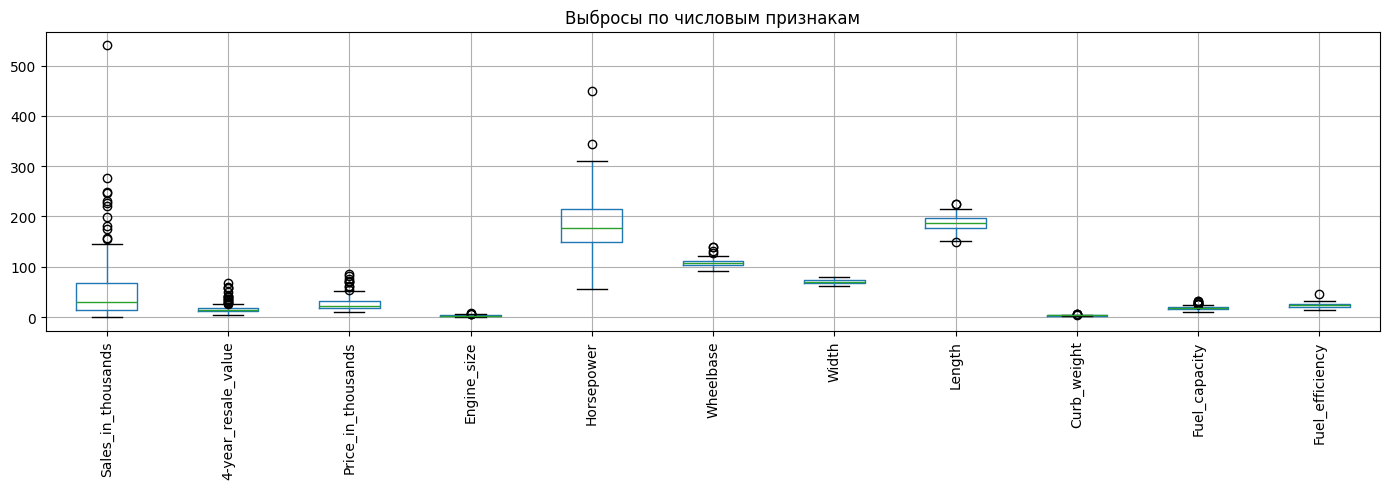

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url1 = 'https://raw.githubusercontent.com/chandanverma07/DataSets/master/Car_sales.csv'
df1 = pd.read_csv(url1)

df1.columns = df1.columns.str.strip().str.replace(' ', '_')
df1 = df1.replace('.', pd.NA)

text_cols1 = ['Manufacturer', 'Model', 'Vehicle_type', 'Latest_Launch']
for col in df1.columns:
  if col not in text_cols1:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

num_cols1 = df1.select_dtypes(include='number').columns
df1[num_cols1] = df1[num_cols1].fillna(df1[num_cols1].median())

print(df1.head())
print()
print(df1.isnull().sum())

df1.boxplot(figsize=(14, 5), rot=90)
plt.title('Выбросы по числовым признакам')
plt.tight_layout()
plt.show()

- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

Размер: (157, 15)

Manufacturer            object
Model                   object
Sales_in_thousands     float64
4-year_resale_value    float64
Vehicle_type            object
Price_in_thousands     float64
Engine_size            float64
Horsepower             float64
Wheelbase              float64
Width                  float64
Length                 float64
Curb_weight            float64
Fuel_capacity          float64
Fuel_efficiency        float64
Latest_Launch           object
dtype: object

         Manufacturer              Model  Sales_in_thousands  \
count             157                157          157.000000   
unique             30                156                 NaN   
top     Ford           Neon                              NaN   
freq               11                  2                 NaN   
mean              NaN                NaN           52.998076   
std               NaN                NaN           68.029422   
min               NaN                NaN            0

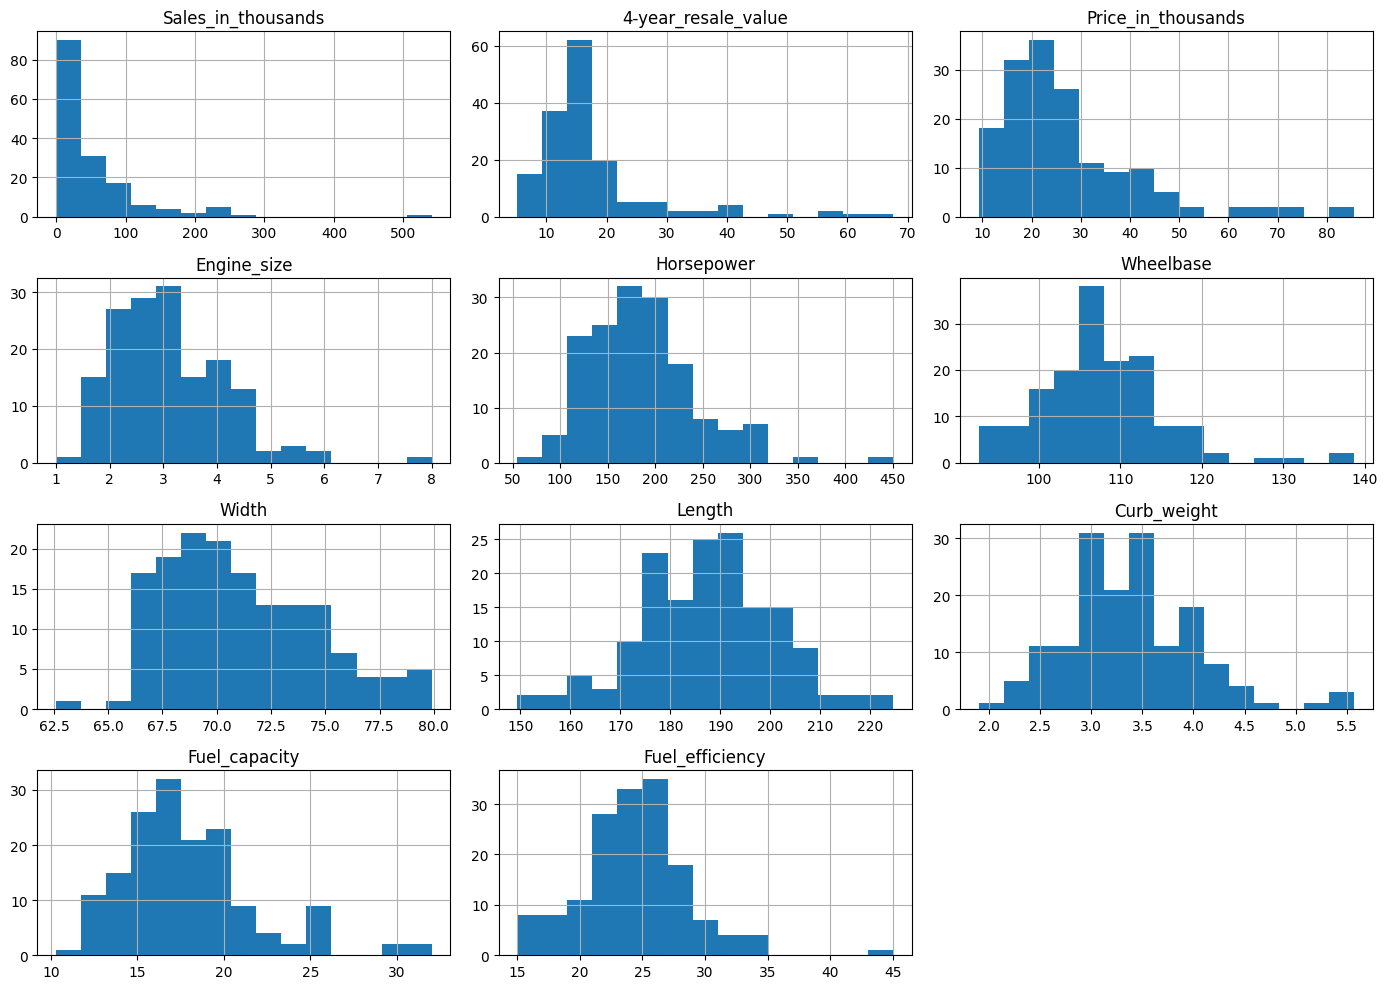

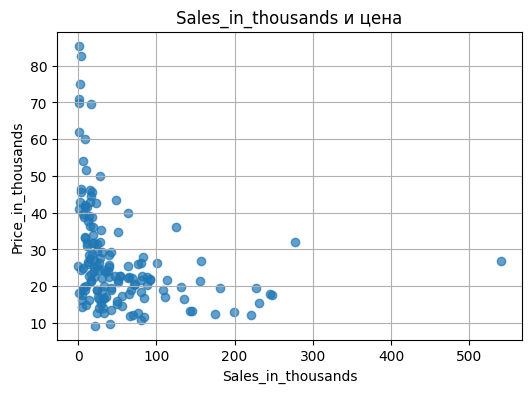

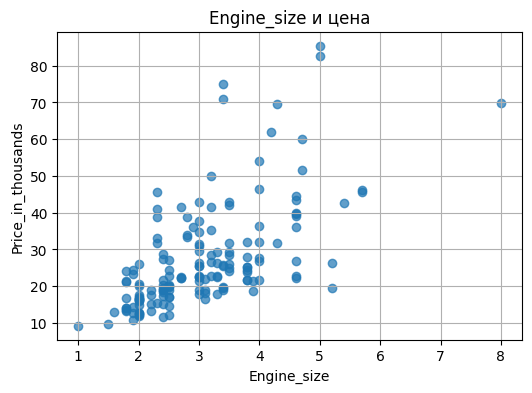

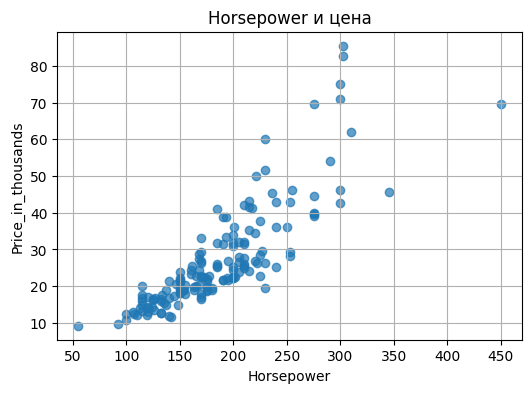

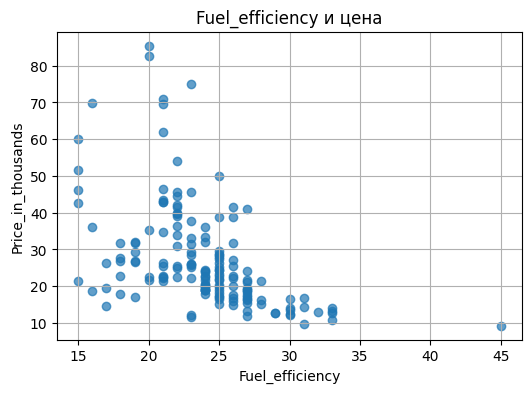

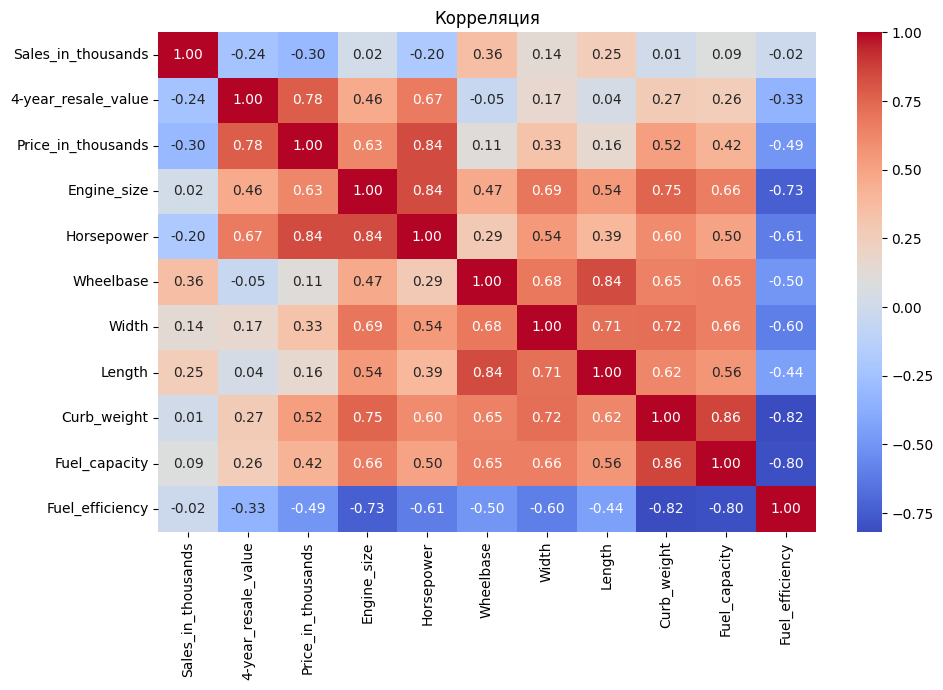

In [5]:
print('Размер:', df1.shape)
print()
print(df1.dtypes)
print()
print(df1.describe(include='all'))

num_cols1 = df1.select_dtypes(include='number').columns
df1[num_cols1].hist(figsize=(14, 10), bins=15)
plt.tight_layout()
plt.show()

for col in ['Sales_in_thousands', 'Engine_size', 'Horsepower', 'Fuel_efficiency']:
  if col in df1.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(df1[col], df1['Price_in_thousands'], alpha=0.7)
    plt.xlabel(col)
    plt.ylabel('Price_in_thousands')
    plt.title(f'{col} и цена')
    plt.grid(True)
    plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df1[num_cols1].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция')
plt.tight_layout()
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target1 = 'Price_in_thousands'

obj_cols1 = df1.select_dtypes(include='object').columns
for col in obj_cols1:
  df1[col] = df1[col].fillna(df1[col].mode()[0])

df1 = df1.dropna(subset=[target1])

X1 = df1.drop(columns=[target1, 'Model', 'Latest_Launch'])
y1 = df1[target1]

X1 = pd.get_dummies(X1, drop_first=True)

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)

scaler1 = StandardScaler()
X_train1_scaled = scaler1.fit_transform(X_train1)
X_test1_scaled = scaler1.transform(X_test1)

print(X_train1.shape, X_test1.shape)

(109, 40) (48, 40)


- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

models1 = {}
best_params1 = {}

lin1 = LinearRegression()
lin1.fit(X_train1_scaled, y_train1)
models1['LinearRegression'] = lin1
best_params1['LinearRegression'] = 'без подбора'

ridge_search1 = GridSearchCV(
    Ridge(),
    param_grid={'alpha': np.logspace(-4, 4, 20)},
    cv=5,
    scoring='neg_mean_squared_error'
)
ridge_search1.fit(X_train1_scaled, y_train1)
models1['Ridge'] = ridge_search1.best_estimator_
best_params1['Ridge'] = ridge_search1.best_params_

lasso_search1 = RandomizedSearchCV(
    Lasso(max_iter=10000),
    param_distributions={'alpha': np.logspace(-4, 4, 50)},
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)
lasso_search1.fit(X_train1_scaled, y_train1)
models1['Lasso'] = lasso_search1.best_estimator_
best_params1['Lasso'] = lasso_search1.best_params_

elastic_search1 = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid={
        'alpha': np.logspace(-4, 2, 10),
        'l1_ratio': [0.2, 0.4, 0.6, 0.8]
        },
    cv=5,
    scoring='neg_mean_squared_error'
)
elastic_search1.fit(X_train1_scaled, y_train1)
models1['ElasticNet'] = elastic_search1.best_estimator_
best_params1['ElasticNet'] = elastic_search1.best_params_

- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results1 = []
preds1 = {}

for name, model in models1.items():
  pred = model.predict(X_test1_scaled)
  preds1[name] = pred
  mse = mean_squared_error(y_test1, pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test1, pred)
  r2 = r2_score(y_test1, pred)
  results1.append([name, mse, rmse, mae, r2])

results_df1 = pd.DataFrame(results1, columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2'])
print(results_df1)

              Model        MSE      RMSE       MAE        R2
0  LinearRegression  82.046755  9.057966  6.147180  0.713794
1             Ridge  52.581882  7.251337  4.549690  0.816577
2             Lasso  54.509372  7.383046  4.707493  0.809854
3        ElasticNet  51.943436  7.207179  4.569243  0.818804


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



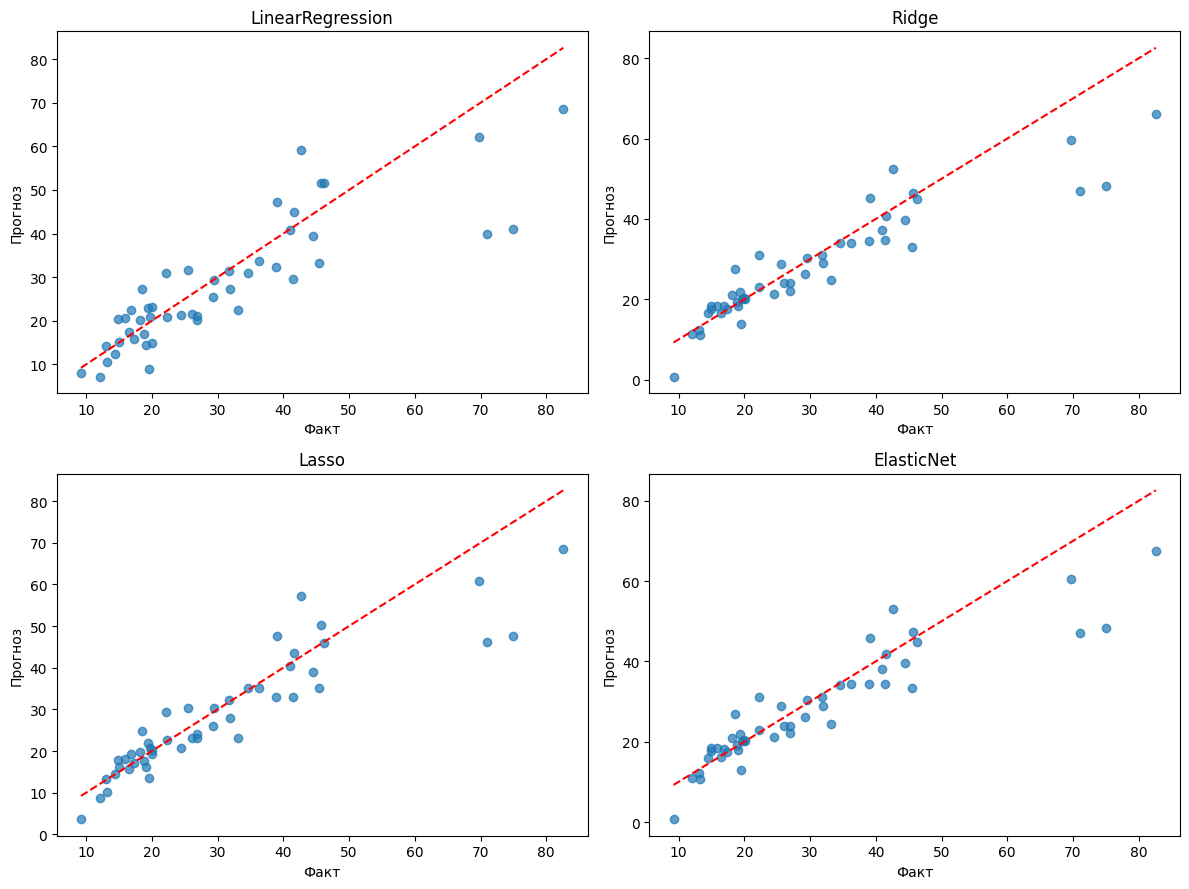

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, preds1.items()):
  ax.scatter(y_test1, pred, alpha=0.7)
  ax.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'r--')
  ax.set_title(name)
  ax.set_xlabel('Факт')
  ax.set_ylabel('Прогноз')

plt.tight_layout()
plt.show()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [16]:
results_df1 = results_df1.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df1)
best_name1 = results_df1.loc[0, 'Model']
print()
print('Лучшая модель:', best_name1)
print('Параметры:', best_params1[best_name1])

              Model        MSE      RMSE       MAE        R2
0        ElasticNet  51.943436  7.207179  4.569243  0.818804
1             Ridge  52.581882  7.251337  4.549690  0.816577
2             Lasso  54.509372  7.383046  4.707493  0.809854
3  LinearRegression  82.046755  9.057966  6.147180  0.713794

Лучшая модель: ElasticNet
Параметры: {'alpha': np.float64(0.21544346900318823), 'l1_ratio': 0.2}


---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

data2 = fetch_openml(data_id=46726, as_frame=True)
df2 = data2.frame.copy()

df2.columns = df2.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')

for col in df2.columns:
    try:
        df2[col] = pd.to_numeric(df2[col])
    except:
        pass

num_cols2 = df2.select_dtypes(include='number').columns
df2[num_cols2] = df2[num_cols2].fillna(df2[num_cols2].median())

print(df2.head())
print()
print(df2.isnull().sum())

df2[num_cols2].boxplot(figsize=(15, 5), rot=90)
plt.title('Выбросы по числовым признакам')
plt.tight_layout()
plt.show()




- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



In [ ]:
target_names2 = [
    'Crop_Yield_MT_per_HA',
    'crop_yield_mt_per_ha',
    'Crop_Yield',
    'crop_yield',
    'Yield',
    'yield'
]

target2 = None
for col in target_names2:
    if col in df2.columns:
        target2 = col
        break

if target2 is None:
    target2 = df2.select_dtypes(include='number').columns[-1]

print('Целевая переменная:', target2)
print('Размер:', df2.shape)
print()
print(df2.dtypes)
print()
print(df2.describe(include='all'))

num_cols2 = df2.select_dtypes(include='number').columns

plt.figure(figsize=(10, 7))
sns.heatmap(df2[num_cols2].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция')
plt.tight_layout()
plt.show()

temp_col2 = None
rain_col2 = None

for col in df2.columns:
    low = col.lower()
    if temp_col2 is None and 'temp' in low:
        temp_col2 = col
    if rain_col2 is None and ('precip' in low or 'rain' in low):
        rain_col2 = col

for col in [temp_col2, rain_col2]:
    if col is not None:
        plt.figure(figsize=(6, 4))
        plt.scatter(df2[col], df2[target2], alpha=0.6)
        plt.xlabel(col)
        plt.ylabel(target2)
        plt.title(f'{col} и урожайность')
        plt.grid(True)
        plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

obj_cols2 = df2.select_dtypes(include='object').columns
for col in obj_cols2:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

df2 = df2.dropna(subset=[target2])

X2 = df2.drop(columns=[target2])
y2 = df2[target2]

X2 = pd.get_dummies(X2, drop_first=True)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

print(X_train2.shape, X_test2.shape)



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

models2 = {}
best_params2 = {}

lin2 = LinearRegression()
lin2.fit(X_train2_scaled, y_train2)
models2['LinearRegression'] = lin2
best_params2['LinearRegression'] = 'без подбора'

ridge_search2 = RandomizedSearchCV(
    Ridge(),
    param_distributions={'alpha': np.logspace(-4, 4, 50)},
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)
ridge_search2.fit(X_train2_scaled, y_train2)
models2['Ridge'] = ridge_search2.best_estimator_
best_params2['Ridge'] = ridge_search2.best_params_

lasso_search2 = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={'alpha': np.logspace(-4, 4, 20)},
    cv=5,
    scoring='neg_mean_squared_error'
)
lasso_search2.fit(X_train2_scaled, y_train2)
models2['Lasso'] = lasso_search2.best_estimator_
best_params2['Lasso'] = lasso_search2.best_params_

elastic_search2 = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid={
        'alpha': np.logspace(-4, 2, 10),
        'l1_ratio': [0.2, 0.4, 0.6, 0.8]
    },
    cv=5,
    scoring='neg_mean_squared_error'
)
elastic_search2.fit(X_train2_scaled, y_train2)
models2['ElasticNet'] = elastic_search2.best_estimator_
best_params2['ElasticNet'] = elastic_search2.best_params_

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results2 = []
preds2 = {}

for name, model in models2.items():
    pred = model.predict(X_test2_scaled)
    preds2[name] = pred

    mse = mean_squared_error(y_test2, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test2, pred)
    r2 = r2_score(y_test2, pred)

    results2.append([name, mse, rmse, mae, r2])

results_df2 = pd.DataFrame(results2, columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2'])
print(results_df2)



- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, preds2.items()):
    ax.scatter(y_test2, pred, alpha=0.7)
    ax.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel('Факт')
    ax.set_ylabel('Прогноз')

plt.tight_layout()
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [ ]:
results_df2 = results_df2.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df2)

best_name2 = results_df2.loc[0, 'Model']
print()
print('Лучшая модель:', best_name2)
print('Параметры:', best_params2[best_name2])

- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



In [ ]:
best_model2 = models2[best_name2]

coef_df2 = pd.DataFrame({
    'feature': X2.columns,
    'coef': best_model2.coef_
})

coef_df2['abs_coef'] = coef_df2['coef'].abs()
coef_df2 = coef_df2.sort_values('abs_coef', ascending=False)

print('Самые сильные признаки:')
print(coef_df2[['feature', 'coef']].head(10))
print()
print('Положительные коэффициенты:')
print(coef_df2[coef_df2['coef'] > 0][['feature', 'coef']].head(5))
print()
print('Отрицательные коэффициенты:')
print(coef_df2[coef_df2['coef'] < 0][['feature', 'coef']].head(5))

top10 = coef_df2.head(10).sort_values('coef')

plt.figure(figsize=(9, 6))
plt.barh(top10['feature'], top10['coef'])
plt.title('Топ признаков по коэффициентам')
plt.xlabel('Коэффициент')
plt.tight_layout()
plt.show()

#### **Интерпретация результатов (пример формулировки для отчёта):**


По таблице выше видно, какие признаки сильнее всего влияют на урожайность. Плюс в коэффициенте значит рост прогноза, минус — снижение. Для вывода можно брать самые большие по модулю коэффициенты.

- самые важные признаки смотрим в начале таблицы;
- положительные коэффициенты повышают прогноз урожайности;
- отрицательные коэффициенты понижают прогноз урожайности.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url3 = 'https://raw.githubusercontent.com/Bahaakhalled/Bank-Marketing-Classification/main/bank.csv'
df3 = pd.read_csv(url3, sep=';')

num_cols3 = df3.select_dtypes(include='number').columns
df3[num_cols3] = df3[num_cols3].fillna(df3[num_cols3].median())

obj_cols3 = df3.select_dtypes(include='object').columns
for col in obj_cols3:
    df3[col] = df3[col].fillna(df3[col].mode()[0])

print(df3.head())
print()
print(df3.isnull().sum())

df3[num_cols3].boxplot(figsize=(12, 5), rot=90)
plt.title('Выбросы по числовым признакам')
plt.tight_layout()
plt.show()

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [ ]:
print('Размер:', df3.shape)
print()
print(df3.dtypes)
print()
print(df3['y'].value_counts())

df3['y'] = df3['y'].map({'no': 0, 'yes': 1})

X3 = df3.drop(columns=['y'])
X3 = pd.get_dummies(X3, drop_first=True)
y3 = df3['y']

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.3, random_state=42, stratify=y3
)

scaler3 = StandardScaler()
X_train3_scaled = scaler3.fit_transform(X_train3)
X_test3_scaled = scaler3.transform(X_test3)

print(X_train3.shape, X_test3.shape)

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

models3 = {}
best_params3 = {}

l2_search3 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000),
    param_grid={'C': np.logspace(-2, 2, 10)},
    cv=5,
    scoring='roc_auc'
)
l2_search3.fit(X_train3_scaled, y_train3)
models3['L2'] = l2_search3.best_estimator_
best_params3['L2'] = l2_search3.best_params_

l1_search3 = RandomizedSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=5000),
    param_distributions={'C': np.logspace(-2, 2, 30)},
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    random_state=42
)
l1_search3.fit(X_train3_scaled, y_train3)
models3['L1'] = l1_search3.best_estimator_
best_params3['L1'] = l1_search3.best_params_

elastic_search3 = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000),
    param_grid={
        'C': np.logspace(-2, 2, 6),
        'l1_ratio': [0.2, 0.4, 0.6, 0.8]
    },
    cv=5,
    scoring='roc_auc'
)
elastic_search3.fit(X_train3_scaled, y_train3)
models3['ElasticNet'] = elastic_search3.best_estimator_
best_params3['ElasticNet'] = elastic_search3.best_params_


- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

results3 = []
roc_curves3 = {}
conf_matrices3 = {}

for name, model in models3.items():
    pred = model.predict(X_test3_scaled)
    proba = model.predict_proba(X_test3_scaled)[:, 1]

    acc = accuracy_score(y_test3, pred)
    prec = precision_score(y_test3, pred)
    rec = recall_score(y_test3, pred)
    f1 = f1_score(y_test3, pred)
    auc = roc_auc_score(y_test3, proba)

    results3.append([name, acc, prec, rec, f1, auc])
    conf_matrices3[name] = confusion_matrix(y_test3, pred)

    fpr, tpr, _ = roc_curve(y_test3, proba)
    roc_curves3[name] = [fpr, tpr, auc]

results_df3 = pd.DataFrame(
    results3,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
)
print(results_df3)

for name, matrix in conf_matrices3.items():
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Матрица ошибок: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



In [ ]:
plt.figure(figsize=(8, 6))

for name, values in roc_curves3.items():
    fpr, tpr, auc = values
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(True)
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

In [ ]:
results_df3 = results_df3.sort_values('AUC', ascending=False).reset_index(drop=True)
print(results_df3)

best_name3 = results_df3.loc[0, 'Model']
print()
print('Лучшая модель:', best_name3)
print('Параметры:', best_params3[best_name3])

plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrices3[best_name3], annot=True, fmt='d', cmap='Blues')
plt.title(f'Лучшая модель: {best_name3}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()